# Discontinuity detection

## Imports

In [1]:
# --- Standard library ---
import sys                                 # system params
from pathlib import Path                   # OO paths

# --- Third-party packages ---
try:
    import numpy as np                     # numerical arrays
except ImportError as e:
    raise RuntimeError("Missing 'numpy'. Install:\n  pip install numpy") from e

try:
    import pandas as pd                    # tabular data
except ImportError as e:
    raise RuntimeError("Missing 'pandas'. Install:\n  pip install pandas") from e

try:
    import matplotlib.pyplot as plt        # plotting
except ImportError as e:
    raise RuntimeError("Missing 'matplotlib'. Install:\n  pip install matplotlib") from e

try:
    import statsmodels.nonparametric.smoothers_lowess  # required by detect_jumps_lowess
except ImportError as e:
    raise RuntimeError("Missing 'statsmodels'. Install:\n  pip install statsmodels") from e

# --- Doris library ---
_src = Path("../..").resolve() / "src"
if str(_src) not in sys.path:
    sys.path.insert(0, str(_src))

try:
    from doris.analysis.stations.trend import fit_piecewise_trend
    from doris.analysis.stations.discontinuities import (
        detect_jumps_sliding_window,
        detect_jumps_lowess,
    )
    from doris.output.tables import Col, save_latex_table
except ImportError as e:
    raise RuntimeError(
        "Cannot import doris. Make sure 'src/' is in sys.path.\n"
        "Original error: " + str(e)
    )


## Paths and constants


In [2]:
# --- Dataset selection ---
PRODUCT = "stcd"       # product, e.g. "stcd", "eop"
SOLUTION = "gop25wd04" # solution version
STATION = "KIVC"       # station code, e.g. "LICB", "CADB"

COMPONENTS = ["dE", "dN", "dU"]

# --- Input data ---
# "raw"  = selected station coordinates
# "detr" = residuals after trend removal
# "aper" = residuals after trend and periodicity removal
INPUT_TYPE = "detr"

# Used only for "detr" and "aper" inputs.
TREND_VARIANT = "weighted_1seg"  # weighted_1seg, weighted_2seg, weighted_multiseg

# --- Detection parameters ---

# Method 1: sliding window
window_size = 40       # W: window length [samples]
shift = 40             # s: offset between windows [samples]
sw_mode = "heuristic" # "heuristic" or "t_test"
sigma_mult = 0.7     # threshold = sigma_mult * sigma (heuristic only)
sw_alpha = 0.05       # significance level (t_test only)

# Method 2: LOWESS + derivative
frac_lowess = 0.25     # smoothing fraction (smaller = less smooth)
lw_mode = "z_test"    # "heuristic" or "z_test"
k_sigma_slope = 2.0   # threshold = k_sigma_slope * sigma_slope (heuristic only)
min_slope_abs = 3.0   # minimum absolute threshold [mm/yr]
lw_alpha = 0.05       # significance level (z_test only)


# --- Paths ---
PROJECT_ROOT = Path("../..").resolve()
DATA_DIR = PROJECT_ROOT / "data" / PRODUCT / SOLUTION
EXPORT_DIR = DATA_DIR / "exports" / STATION.lower()
IMAGES_DIR = PROJECT_ROOT / "LaTeX" / "images" / "results" / "stations" / STATION.lower()
TABLES_DIR = PROJECT_ROOT / "LaTeX" / "tables" / "results" / "stations" / STATION.lower()

# Create dirs
for d in [DATA_DIR, EXPORT_DIR, IMAGES_DIR, TABLES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

BASE_NAME = f"{SOLUTION}_{PRODUCT}_{STATION.lower()}"

if INPUT_TYPE == "raw":
    INPUT_CSV = EXPORT_DIR / f"{BASE_NAME}_selected_data.csv"
    IMAGE_NAME = f"{BASE_NAME}_raw"
elif INPUT_TYPE in {"detr", "aper"}:
    INPUT_CSV = EXPORT_DIR / f"{BASE_NAME}_{INPUT_TYPE}_{TREND_VARIANT}.csv"
    IMAGE_NAME = f"{BASE_NAME}_{INPUT_TYPE}_{TREND_VARIANT}"
else:
    raise ValueError("INPUT_TYPE must be 'raw', 'detr', or 'aper'.")

TREND_LABELS = {
    "weighted_1seg": "lineárního trendu",
    "weighted_2seg": "segmentovaného trendu se dvěma segmenty",
    "weighted_multiseg": "segmentovaného trendu",
}

if INPUT_TYPE == "raw":
    SOURCE_LABEL = "vybraných staničních souřadnic"
elif INPUT_TYPE == "detr":
    SOURCE_LABEL = f"reziduí po odečtení {TREND_LABELS.get(TREND_VARIANT, TREND_VARIANT)}"
else:
    SOURCE_LABEL = f"aperiodických reziduí po odečtení {TREND_LABELS.get(TREND_VARIANT, TREND_VARIANT)}"


print("Project: ", PROJECT_ROOT)
print("Data:    ", EXPORT_DIR)
print("Input:   ", INPUT_CSV.name)
print("Source:  ", SOURCE_LABEL)


def format_years(values, decimals=3):
    if len(values) == 0:
        return "-"
    return ", ".join(f"{float(value):.{decimals}f}" for value in values)


Project:  C:\Users\michal\Desktop\MasterThesis-DorisAnalysis
Data:     C:\Users\michal\Desktop\MasterThesis-DorisAnalysis\data\stcd\gop25wd04\exports\kivc
Input:    gop25wd04_stcd_kivc_detr_weighted_1seg.csv
Source:   reziduí po odečtení lineárního trendu


In [3]:
# --- Load input data ---
if not INPUT_CSV.exists():
    if INPUT_TYPE == "raw":
        candidates = sorted(EXPORT_DIR.glob("*_selected_data.csv"))
    else:
        candidates = sorted(EXPORT_DIR.glob(f"*_{INPUT_TYPE}_*.csv"))

    hint = "\n".join(f"  - {p.name}" for p in candidates) or "  (no files found)"
    raise FileNotFoundError(
        f"File not found:\n  {INPUT_CSV}\n\nAvailable files:\n{hint}"
    )

df_input = pd.read_csv(INPUT_CSV)

if INPUT_TYPE == "raw":
    VALUE_COLS = {comp: comp for comp in COMPONENTS}
elif INPUT_TYPE == "detr":
    VALUE_COLS = {comp: f"res_{comp}" for comp in COMPONENTS}
else:
    VALUE_COLS = {comp: f"aper_{comp}" for comp in COMPONENTS}

missing = ["year", *VALUE_COLS.values()]
missing = [col for col in missing if col not in df_input.columns]
if missing:
    raise KeyError(f"Missing required column(s): {missing}")

df_input = df_input.sort_values("year").reset_index(drop=True)

print(f"Loaded {len(df_input)} rows from {INPUT_CSV.name}")
print("Using columns:", ", ".join(VALUE_COLS.values()))
df_input[["year", *VALUE_COLS.values()]].head()


Loaded 472 rows from gop25wd04_stcd_kivc_detr_weighted_1seg.csv
Using columns: res_dE, res_dN, res_dU


,year,res_dE,res_dN,res_dU
0,2016.454918,-29.128517,-14.361887,38.189182
1,2016.474044,1.815445,-11.943036,2.503041
2,2016.493169,5.459407,5.575814,3.616900
3,2016.512295,5.403369,-5.905335,-0.769240
4,2016.531421,16.147331,-4.586485,10.844619


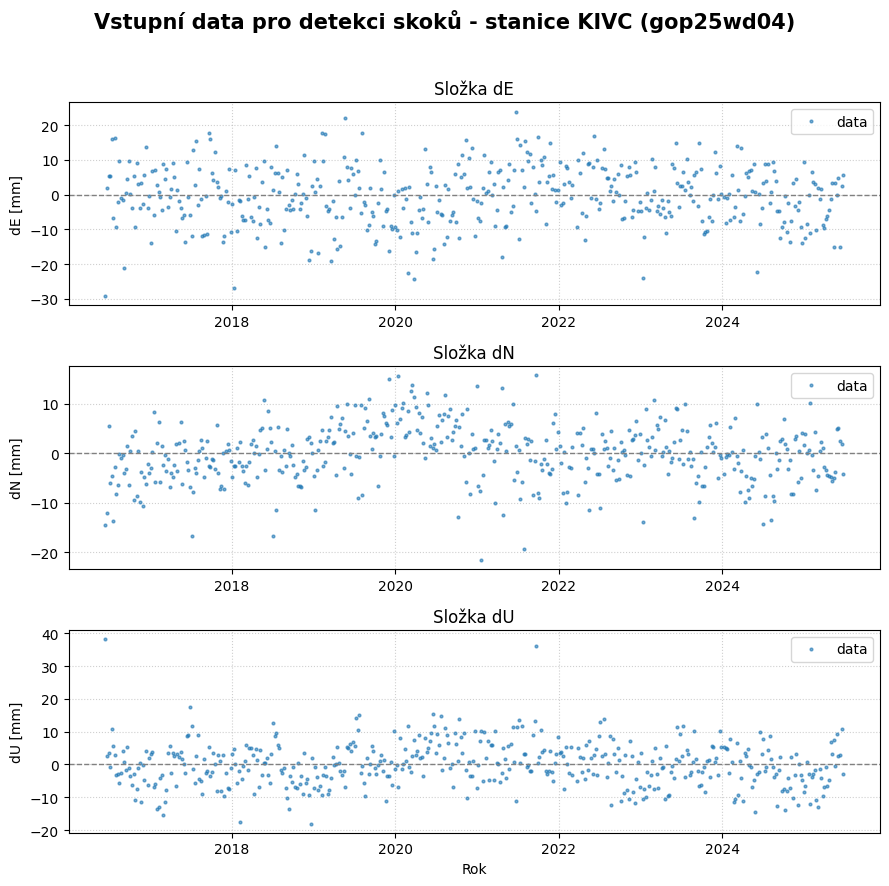

In [4]:
# --- Plot input residuals ---
component_titles = {
    "dE": "Složka dE",
    "dN": "Složka dN",
    "dU": "Složka dU",
}

station_title = f"stanice {STATION.upper()} ({SOLUTION})"

fig, axes = plt.subplots(3, 1, figsize=(9, 9), sharex=True)

for ax, comp in zip(axes, COMPONENTS):
    y = df_input[VALUE_COLS[comp]]
    ax.plot(df_input["year"], y, ".", ms=4, alpha=0.6, label="data")
    ax.axhline(0, color="gray", linestyle="--", linewidth=1)
    ax.set_title(component_titles.get(comp, comp), fontweight="normal")
    ax.set_ylabel(f"{comp} [mm]")
    ax.tick_params(axis="x", labelbottom=True)
    ax.grid(True, linestyle=":", alpha=0.6)
    ax.legend()

axes[-1].set_xlabel("Rok")

fig.suptitle(
    f"Vstupní data pro detekci skoků - {station_title}",
    fontsize=15,
    fontweight="bold",
)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


## Method 1: Sliding window


In [5]:
# Sliding-window jump detection
years = df_input["year"].to_numpy()
sw_results = {}

for comp in COMPONENTS:
    y = df_input[VALUE_COLS[comp]].fillna(0).to_numpy()
    sw_results[comp] = detect_jumps_sliding_window(
        years, y,
        window_size=window_size, shift=shift,
        threshold_mode=sw_mode, sigma_mult=sigma_mult, alpha=sw_alpha,
    )

print("Sliding-window detection done.")
for comp in COMPONENTS:
    r = sw_results[comp]
    print(f"  {comp}: {len(r)} jump(s),  threshold={r.threshold:.2f} mm")


Sliding-window detection done.
  dE: 16 jump(s),  threshold=5.89 mm
  dN: 69 jump(s),  threshold=4.03 mm
  dU: 15 jump(s),  threshold=4.71 mm


In [6]:
from doris.output.tables import Col, save_latex_table

# --- Helpers: group close detections into compact date intervals ---

def decimal_year_to_date(x):
    year = int(float(x))
    date = pd.Timestamp(year, 1, 1) + pd.Timedelta(days=(float(x) - year) * 365.25)
    return f"{date.day}. {date.month}. {date.year}"


def group_years(years, max_gap=0.08):
    vals = sorted(float(y) for y in years if pd.notna(y))

    if not vals:
        return []

    groups = [[vals[0]]]

    for y in vals[1:]:
        if y - groups[-1][-1] <= max_gap:
            groups[-1].append(y)
        else:
            groups.append([y])

    return groups


def format_year_group_as_dates(group):
    start = decimal_year_to_date(group[0])
    end = decimal_year_to_date(group[-1])

    if start == end:
        return start

    return f"{start} -- {end}"


def format_grouped_years_as_dates(years, max_gap=0.08):
    groups = group_years(years, max_gap=max_gap)

    if not groups:
        return "--"

    return ", ".join(
        format_year_group_as_dates(group)
        for group in groups
    )


# --- Sliding-window LaTeX table ---

max_group_gap = 0.08  # ~1 month in decimal years

sw_table_df = pd.DataFrame([
    {
        "axis": comp,
        "n_detections": len(sw_results[comp].jumps),
        "n_groups": len(group_years(sw_results[comp].jumps, max_gap=max_group_gap)),
        "jumps": format_grouped_years_as_dates(
            sw_results[comp].jumps,
            max_gap=max_group_gap,
        ),
        "criterion": (
            f"$\\sigma \\cdot {sigma_mult}$"
            if sw_mode == "heuristic"
            else f"t-test $\\alpha={sw_alpha}$"
        ),
    }
    for comp in COMPONENTS
])

tex_file = TABLES_DIR / f"{IMAGE_NAME}_jumps_sliding_window.tex"

latex_sw = save_latex_table(
    sw_table_df,
    tex_file,
    cols=[
        Col("axis", "Složka", None),
        Col("n_detections", "Detekce", None),
        Col("n_groups", "Skupiny", None),
        Col("jumps", "Intervaly", None),
        Col("criterion", "Kritérium", None),
    ],
    index=False,
    caption=(
        f"Detekce skoků metodou dvou pohyblivých oken ze {SOURCE_LABEL} "
        f"pro stanici {STATION.upper()} a řešení {SOLUTION}."
    ),
    label=f"tab:{IMAGE_NAME}_jumps_sliding_window",
    escape=False,
    position="H",
    centering=True,
    font_size="\\small",
    print_preview=True,
)

print("Saved TeX ->", tex_file.resolve())

\begin{table}[H]
\centering
\small
\caption{Detekce skoků metodou dvou pohyblivých oken ze reziduí po odečtení lineárního trendu pro stanici KIVC a řešení gop25wd04.}
\label{tab:gop25wd04_stcd_kivc_detr_weighted_1seg_jumps_sliding_window}
\begin{tabular}{lllll}
\toprule
Složka & Detekce & Skupiny & Intervaly & Kritérium \\
\midrule
dE & 16 & 2 & 11. 8. 2019 -- 25. 8. 2019, 22. 8. 2020 -- 21. 11. 2020 & $\sigma \cdot 0.7$ \\
dN & 69 & 3 & 17. 2. 2019 -- 1. 9. 2019, 23. 5. 2020 -- 17. 1. 2021, 30. 7. 2023 -- 27. 8. 2023 & $\sigma \cdot 0.7$ \\
dU & 15 & 3 & 5. 5. 2019 -- 9. 6. 2019, 21. 8. 2022 -- 2. 10. 2022, 3. 8. 2024 -- 17. 8. 2024 & $\sigma \cdot 0.7$ \\
\bottomrule
\end{tabular}
\end{table}

Saved TeX -> C:\Users\michal\Desktop\MasterThesis-DorisAnalysis\LaTeX\tables\results\stations\kivc\gop25wd04_stcd_kivc_detr_weighted_1seg_jumps_sliding_window.tex


Saved PDF -> C:\Users\michal\Desktop\MasterThesis-DorisAnalysis\LaTeX\images\results\stations\kivc\gop25wd04_stcd_kivc_detr_weighted_1seg_sliding_window.pdf
Saved PNG -> C:\Users\michal\Desktop\MasterThesis-DorisAnalysis\LaTeX\images\results\stations\kivc\gop25wd04_stcd_kivc_detr_weighted_1seg_sliding_window.png


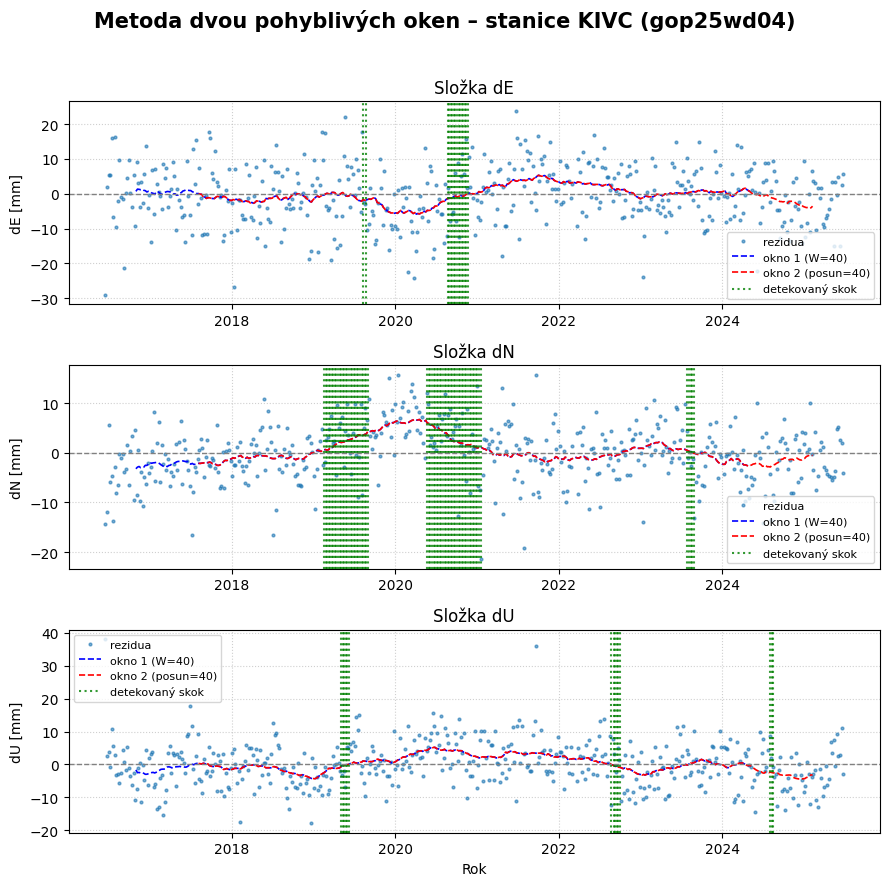

In [7]:
fig, axes = plt.subplots(3, 1, figsize=(9, 9), sharex=True)

for ax, comp in zip(axes, COMPONENTS):
    y = df_input[VALUE_COLS[comp]].to_numpy()
    x = df_input["year"].to_numpy()
    r = sw_results[comp]
    e = r.extras

    ax.plot(x, y, ".", ms=4, alpha=0.6, label="rezidua")
    ax.plot(e["years1"], e["mu1"], "b--", lw=1.2, label=f"okno 1 (W={e['window_size']})")
    ax.plot(e["years2"], e["mu2"], "r--", lw=1.2, label=f"okno 2 (posun={e['shift']})")

    first = True
    for xv in r.jumps:
        ax.axvline(xv, color="green", linestyle=":", alpha=0.8,
                   label="detekovaný skok" if first else None)
        first = False

    ax.axhline(0, color="gray", ls="--", lw=1)
    method_label = f"σ×{sigma_mult}" if sw_mode == "heuristic" else f"t-test α={sw_alpha}"
    ax.set_title(component_titles.get(comp, comp), fontweight="normal")
    ax.set_ylabel(f"{comp} [mm]")
    ax.tick_params(axis="x", labelbottom=True)
    ax.grid(True, ls=":", alpha=0.6)
    ax.legend(fontsize=8)

axes[-1].set_xlabel("Rok")
fig.suptitle(
    f"Metoda dvou pohyblivých oken – stanice {STATION.upper()} ({SOLUTION})",
    fontsize=15,
    fontweight="bold",
)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plot_file = IMAGES_DIR / f"{IMAGE_NAME}_sliding_window.pdf"
png_file = plot_file.with_suffix(".png")
fig.savefig(plot_file, bbox_inches="tight", dpi=150)
fig.savefig(png_file, bbox_inches="tight", dpi=150)
print("Saved PDF ->", plot_file.resolve())
print("Saved PNG ->", png_file.resolve())
plt.show()


## Method 2: LOWESS smoothing + derivative


In [8]:
# LOWESS derivative jump detection
lw_results = {}

for comp in COMPONENTS:
    y = df_input[VALUE_COLS[comp]].fillna(0).to_numpy()
    lw_results[comp] = detect_jumps_lowess(
        years, y,
        frac=frac_lowess,
        threshold_mode=lw_mode, k_sigma=k_sigma_slope,
        min_abs=min_slope_abs, alpha=lw_alpha,
    )

print(f"LOWESS detection done.  frac={frac_lowess}, k={k_sigma_slope}, min={min_slope_abs}")
for comp in COMPONENTS:
    r = lw_results[comp]
    print(f"  {comp}: {len(r)} jump(s),  threshold={r.threshold:.2f} mm/yr")


LOWESS detection done.  frac=0.25, k=2.0, min=3.0
  dE: 68 jump(s),  threshold=3.33 mm/yr
  dN: 26 jump(s),  threshold=4.90 mm/yr
  dU: 39 jump(s),  threshold=3.83 mm/yr


In [9]:
# --- LOWESS derivative LaTeX table ---

max_group_gap = 0.08  # ~1 month in decimal years

lw_table_df = pd.DataFrame([
    {
        "axis": comp,
        "n_detections": len(lw_results[comp].jumps),
        "n_groups": len(group_years(lw_results[comp].jumps, max_gap=max_group_gap)),
        "jumps": format_grouped_years_as_dates(
            lw_results[comp].jumps,
            max_gap=max_group_gap,
        ),
        "threshold": lw_results[comp].threshold,
        "criterion": (
            f"$k={k_sigma_slope}$, min={min_slope_abs}"
            if lw_mode == "heuristic"
            else f"z-test $\\alpha={lw_alpha}$"
        ),
    }
    for comp in COMPONENTS
])

tex_file = TABLES_DIR / f"{IMAGE_NAME}_jumps_lowess_derivative.tex"

latex_lw = save_latex_table(
    lw_table_df,
    tex_file,
    cols=[
        Col("axis", "Složka", None),
        Col("n_detections", "Detekce", None),
        Col("n_groups", "Skupiny", None),
        Col("jumps", "Intervaly", None),
        Col("threshold", "Práh [mm/rok]", 3),
        Col("criterion", "Kritérium", None),
    ],
    index=False,
    caption=(
        f"Detekce skoků pomocí derivace vyhlazené křivky ze {SOURCE_LABEL} "
        f"pro stanici {STATION.upper()} a řešení {SOLUTION}."
    ),
    label=f"tab:{IMAGE_NAME}_jumps_lowess_derivative",
    escape=False,
    position="H",
    centering=True,
    font_size="\\small",
    print_preview=True,
)

print("Saved TeX ->", tex_file.resolve())

\begin{table}[H]
\centering
\small
\caption{Detekce skoků pomocí derivace vyhlazené křivky ze reziduí po odečtení lineárního trendu pro stanici KIVC a řešení gop25wd04.}
\label{tab:gop25wd04_stcd_kivc_detr_weighted_1seg_jumps_lowess_derivative}
\begin{tabular}{llllrl}
\toprule
Složka & Detekce & Skupiny & Intervaly & Práh [mm/rok] & Kritérium \\
\midrule
dE & 68 & 4 & 26. 5. 2019, 20. 6. 2020 -- 23. 5. 2021, 10. 4. 2022 -- 31. 7. 2022, 18. 5. 2024 & 3.328 & z-test $\alpha=0.05$ \\
dN & 26 & 2 & 21. 4. 2019 -- 4. 8. 2019, 14. 11. 2020 -- 17. 1. 2021 & 4.898 & z-test $\alpha=0.05$ \\
dU & 39 & 2 & 16. 6. 2019 -- 29. 12. 2019, 10. 4. 2022 -- 12. 6. 2022 & 3.827 & z-test $\alpha=0.05$ \\
\bottomrule
\end{tabular}
\end{table}

Saved TeX -> C:\Users\michal\Desktop\MasterThesis-DorisAnalysis\LaTeX\tables\results\stations\kivc\gop25wd04_stcd_kivc_detr_weighted_1seg_jumps_lowess_derivative.tex


Saved PDF -> C:\Users\michal\Desktop\MasterThesis-DorisAnalysis\LaTeX\images\results\stations\kivc\gop25wd04_stcd_kivc_detr_weighted_1seg_lowess_derivate.pdf
Saved PNG -> C:\Users\michal\Desktop\MasterThesis-DorisAnalysis\LaTeX\images\results\stations\kivc\gop25wd04_stcd_kivc_detr_weighted_1seg_lowess_derivate.png


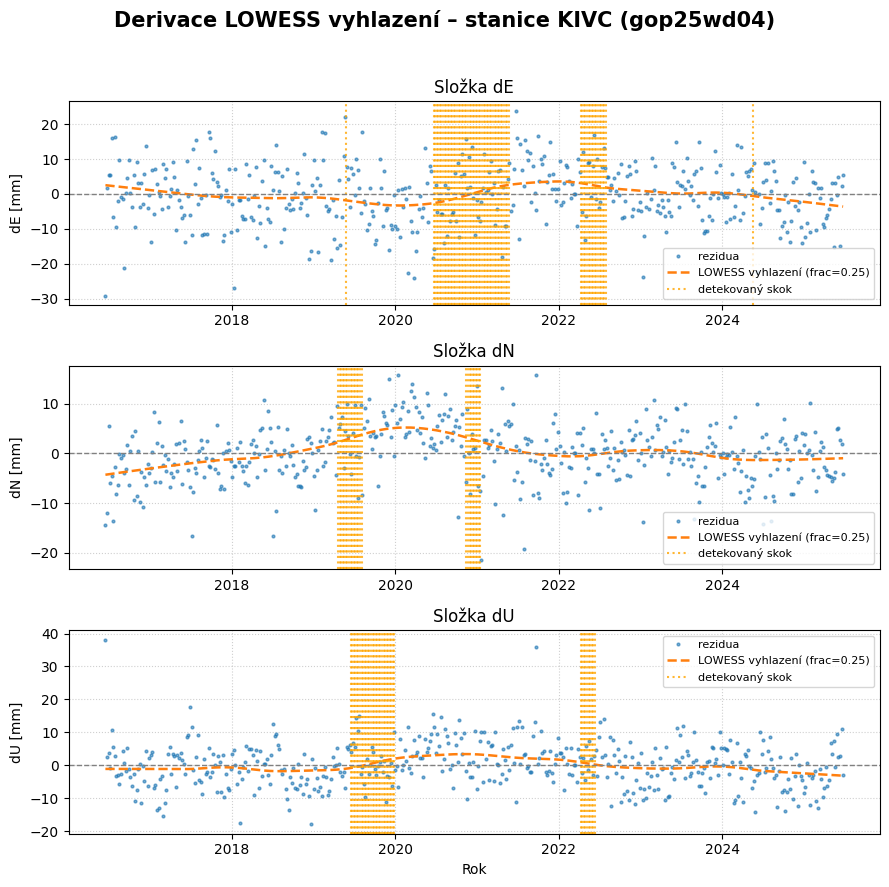

In [10]:
fig, axes = plt.subplots(3, 1, figsize=(9, 9), sharex=True)

for ax, comp in zip(axes, COMPONENTS):
    y = df_input[VALUE_COLS[comp]].fillna(0).to_numpy()
    r = lw_results[comp]
    e = r.extras

    ax.plot(years, y, ".", ms=4, alpha=0.6, label="rezidua")
    ax.plot(years, e["smoothed"], "--", lw=1.8, label=f"LOWESS vyhlazení (frac={e['frac']})")

    first = True
    for xv in r.jumps:
        ax.axvline(xv, color="orange", ls=":", alpha=0.8,
                   label="detekovaný skok" if first else None)
        first = False

    ax.axhline(0, color="gray", ls="--", lw=1)
    method_label = f"k={k_sigma_slope}, min={min_slope_abs} mm/rok" if lw_mode == "heuristic"             else f"z-test α={lw_alpha}, min={min_slope_abs} mm/rok"
    ax.set_title(component_titles.get(comp, comp), fontweight="normal")
    ax.set_ylabel(f"{comp} [mm]")
    ax.tick_params(axis="x", labelbottom=True)
    ax.grid(True, ls=":", alpha=0.6)
    h, l = ax.get_legend_handles_labels()
    ax.legend(dict(zip(l, h)).values(), dict(zip(l, h)).keys(), fontsize=8)

axes[-1].set_xlabel("Rok")
fig.suptitle(
    f"Derivace LOWESS vyhlazení – stanice {STATION.upper()} ({SOLUTION})",
    fontsize=15,
    fontweight="bold",
)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plot_file = IMAGES_DIR / f"{IMAGE_NAME}_lowess_derivate.pdf"
png_file = plot_file.with_suffix(".png")
fig.savefig(plot_file, bbox_inches="tight", dpi=150)
fig.savefig(png_file, bbox_inches="tight", dpi=150)
print("Saved PDF ->", plot_file.resolve())
print("Saved PNG ->", png_file.resolve())
plt.show()


## Method 3: Doris – piecewise linear trend (BIC)

The **doris** library function `fit_piecewise_trend` searches for breakpoints automatically using the BIC criterion.  
Detected breakpoints correspond to potential jumps or trend changes.


In [11]:
# BIC-driven piecewise linear trend – detect breakpoints
bic_results = {}

for comp in COMPONENTS:
    y = df_input[VALUE_COLS[comp]].fillna(0).values

    # max_segments=None: add breakpoints as long as BIC decreases
    result = fit_piecewise_trend(years, y, max_segments=None)
    bic_results[comp] = result

    print(f"{comp}: {result.n_segments} segment(s), BIC={result.bic:.1f}, "
          f"breakpoints={[f'{bp:.3f}' for bp in result.breakpoints]}")


dE: 2 segment(s), BIC=2008.2, breakpoints=['2020.786']
dN: 2 segment(s), BIC=1591.7, breakpoints=['2020.747']
dU: 2 segment(s), BIC=1787.3, breakpoints=['2019.388']


In [12]:
# --- Piecewise model LaTeX table ---
bic_table_df = pd.DataFrame([
    {
        "axis": comp,
        "n_segments": bic_results[comp].n_segments,
        "breakpoints": format_years(bic_results[comp].breakpoints),
        "bic": bic_results[comp].bic,
    }
    for comp in COMPONENTS
])

tex_file = TABLES_DIR / f"{IMAGE_NAME}_jumps_piecewise_bic.tex"

latex_bic = save_latex_table(
    bic_table_df,
    tex_file,
    cols=[
        Col("axis", "Složka", None),
        Col("n_segments", "Počet segmentů", None),
        Col("breakpoints", "Detekované zlomy [rok]", None),
        Col("bic", "BIC", 3),
    ],
    index=False,
    caption=(
        f"Detekce zlomů segmentovaným lineárním modelem ze {SOURCE_LABEL} pro stanici "
        f"{STATION.upper()} a řešení {SOLUTION}."
    ),
    label=f"tab:{IMAGE_NAME}_jumps_piecewise_bic",
    escape=False,
    print_preview=True,
)

print("Saved TeX ->", tex_file.resolve())


\begin{table}[H]
\centering
\caption{Detekce zlomů segmentovaným lineárním modelem ze reziduí po odečtení lineárního trendu pro stanici KIVC a řešení gop25wd04.}
\label{tab:gop25wd04_stcd_kivc_detr_weighted_1seg_jumps_piecewise_bic}
\begin{tabular}{lllr}
\toprule
Složka & Počet segmentů & Detekované zlomy [rok] & BIC \\
\midrule
dE & 2 & 2020.786 & 2008.193 \\
dN & 2 & 2020.747 & 1591.684 \\
dU & 2 & 2019.388 & 1787.321 \\
\bottomrule
\end{tabular}
\end{table}

Saved TeX -> C:\Users\michal\Desktop\MasterThesis-DorisAnalysis\LaTeX\tables\results\stations\kivc\gop25wd04_stcd_kivc_detr_weighted_1seg_jumps_piecewise_bic.tex


Saved PDF -> C:\Users\michal\Desktop\MasterThesis-DorisAnalysis\LaTeX\images\results\stations\kivc\gop25wd04_stcd_kivc_detr_weighted_1seg_doris_piecewise.pdf
Saved PNG -> C:\Users\michal\Desktop\MasterThesis-DorisAnalysis\LaTeX\images\results\stations\kivc\gop25wd04_stcd_kivc_detr_weighted_1seg_doris_piecewise.png


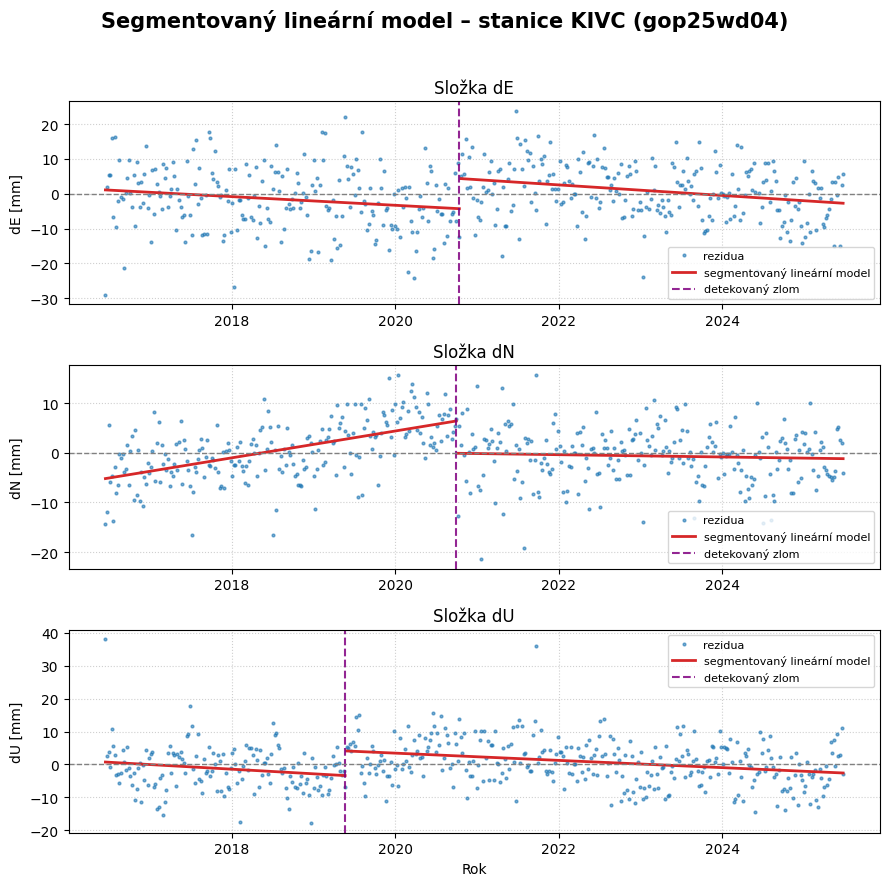

In [13]:
fig, axes = plt.subplots(3, 1, figsize=(9, 9), sharex=True)

for ax, comp in zip(axes, COMPONENTS):
    y = df_input[VALUE_COLS[comp]].fillna(0).to_numpy()
    result = bic_results[comp]

    ax.plot(years, y, ".", ms=4, alpha=0.6, label="rezidua")

    # piecewise fitted line (segment by segment)
    breakpoints = result.breakpoints
    boundaries = [-np.inf] + list(breakpoints) + [np.inf]
    for i in range(len(boundaries) - 1):
        mask = (years > boundaries[i]) & (years <= boundaries[i + 1])
        if mask.any():
            ax.plot(years[mask], result.fitted[mask], "-", lw=2, color="tab:red",
                    label="segmentovaný lineární model" if i == 0 else None)

    # vertical lines at breakpoints
    first = True
    for bp in breakpoints:
        ax.axvline(bp, color="purple", ls="--", alpha=0.85,
                   label="detekovaný zlom" if first else None)
        first = False

    ax.axhline(0, color="gray", ls="--", lw=1)
    ax.set_title(component_titles.get(comp, comp), fontweight="normal")
    ax.set_ylabel(f"{comp} [mm]")
    ax.tick_params(axis="x", labelbottom=True)
    ax.grid(True, ls=":", alpha=0.6)
    h, l = ax.get_legend_handles_labels()
    ax.legend(dict(zip(l, h)).values(), dict(zip(l, h)).keys(), fontsize=8)

axes[-1].set_xlabel("Rok")
fig.suptitle(
    f"Segmentovaný lineární model – stanice {STATION.upper()} ({SOLUTION})",
    fontsize=15,
    fontweight="bold",
)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plot_file = IMAGES_DIR / f"{IMAGE_NAME}_doris_piecewise.pdf"
png_file = plot_file.with_suffix(".png")
fig.savefig(plot_file, bbox_inches="tight", dpi=150)
fig.savefig(png_file, bbox_inches="tight", dpi=150)
print("Saved PDF ->", plot_file.resolve())
print("Saved PNG ->", png_file.resolve())
plt.show()
